# Hail → Solar · M0 input data · source 02 — MRMS MESH (AWS Open Data)

**Asset:** Hayhurst Texas Solar (EIA 66880) · **Peril:** Hail · **Layer:** M0 (raw evidence) · method-neutral

Second M0 source (see [`01_noaa_hydronos`](01_noaa_hydronos.ipynb)). But this one is a **different *kind* of
data**, so we don't jump straight to exploring it — **we start from the very basics and define what the data
actually is.** NOAA came over a simple **API** as a tidy table of events; MRMS is **complex raw open-source
data** (gridded radar files on a public bucket). Meeting complex raw data from scratch — *what is it
physically? what does one file look like? how is the raw data laid out?* — is a deliberate practice for us
(see [`learning_logs/03`](../../../docs/learning_logs/03_meet_complex_raw_data_from_scratch.md)).

So this notebook has two halves:
1. **Understand the data** (§1–§7) — from the mental model down to the actual bytes, numbers, and the
   field→polygon journey. *This is the part NOAA didn't need.*
2. **Explore & emit the M0 record** (§8–§11) — scan the window, build event footprints, write the M0 file.

> Plan: `docs/plans/hail/` · Principles: `docs/principles/notebook_work/`. Reconciling 01 + 02 into one
> clean event set is the **M0→M1** step (the [catalog](../m1_catalog/01_event_catalog.ipynb)), not here.

## 1 · The mental model — NOAA vs MRMS are two different *kinds* of data

This is the whole reason MRMS feels harder than NOAA. They answer the same question ("did it hail, how
big?") but are built completely differently:

| | **NOAA Storm Events** (01) | **MRMS MESH** (this) |
|---|---|---|
| What one record is | **one event**: a person's hail report at a point | **one grid cell**: a radar hail-size estimate at a ~1 km pixel |
| Shape of the data | a **table** (rows = events) | a **grid / image** (a value at every pixel), one per timestamp |
| Event-based? | **yes** — each row *is* an event | **no** — a continuous field; *no* notion of "an event" |
| Footprint / polygon? | no — just a point | not natively — the field *contains* the shape, which **we** extract |
| How you read it | open a spreadsheet | open an image and read pixel values |
| Coverage | wherever a **person** reported (population-biased) | **everywhere** the radar sees (complete) |
| Record length | long (1996→) | short (~2020-10→ on AWS) |
| Delivery | simple **API** (JSON) | raw **files** on a public bucket (GRIB2) |

> **One-sentence model.** *NOAA is a list of events. MRMS is a picture.* MRMS doesn't know what an "event"
> is — it's a grid of hail-size numbers covering the country, through time. **We** turn the picture into
> events. (So: it looks like a *grid/image*; it is **not** event-based; and the polygon is **not** native —
> *we* make it. The rest of §1–§7 shows each of these for real.)

## 2 · What is "MESH", physically?

**MESH = Maximum Estimated Size of Hail.** Each word matters:

- **Maximum** — the *largest* hailstone the radar thinks fell in that cell.
- **Estimated** — a **radar estimate, not a measurement.** Radar measures *reflectivity*; a formula (Severe
  Hail Index → `MESH = 2.54·√SHI`, Witt et al. 1998) converts it to an implied hail size. So MESH is a model
  output with real error — and is tuned to **over-forecast** (~75% of real hail falls *below* it; see
  [`learning_logs/01`](../../../docs/learning_logs/01_extending_a_short_hazard_record.md)).
- **Size of Hail** — output in **millimetres** (25.4 mm = 1 in = the "severe" threshold we use).

Our product, **`MESH_Max_1440min`**, adds: **1440 min = 24 h**, `Max` = the **running 24-h maximum** per
cell. So one tile ≈ *"the biggest hail each 1 km patch saw in the last 24 h"* — i.e. **one tile ≈ one day's
hail map**, and we take one tile per day.

## Assumptions (this layer)

**A1** region = 50-mi circle · **A2** severe threshold = 25.4 mm (1″) · **A3** window = Apr–Jun 2024
*(deferred — widen for a real λ)* · **A4** daily grain = last tile ≈ 24-h max · **A5** MESH is a radar
*estimate* (over-forecasts), not ground truth. Full detail + status + revisit-triggers:
[assumptions A1–A5](../../../docs/plans/hail/assumptions.md#m0--input-data).

In [1]:
from __future__ import annotations
import os, gzip, json, math, tempfile
from pathlib import Path
import xml.etree.ElementTree as ET
import requests
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
from shapely.geometry import box as shp_box
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.colors import ListedColormap

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})

def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / ".env").exists() or (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")
ROOT = _repo_root()

ASSET = {"name": "Hayhurst Texas Solar", "eia_plant_id": 66880, "state": "TX", "county": "Culberson",
         "lat": 31.815992, "lon": -104.0853, "ac_capacity_mw": 24.8, "asset_value_usd": 36_778_400}

# --- config ---
RADIUS_MI    = 50           # match 01's search region (apples-to-apples)
THRESHOLD_MM = 25.4         # 1 inch — NWS severe-hail definition (H10 catalog threshold)
WINDOW       = ("2024-04-01", "2024-06-30")   # STATED, bounded demo window — see §3
PRODUCT      = "CONUS/MESH_Max_1440min_00.50"
SAMPLE       = "20240601"   # a real, big hail day — our worked example through §4–§7
RES_DEG, RES_M = 0.01, 1000
PX_KM2 = (RES_DEG * 111.32) * (RES_DEG * 111.32 * math.cos(math.radians(ASSET["lat"])))   # ~1.05 km²/pixel
print(f"repo root: {ROOT}\nproduct: {PRODUCT}\nwindow: {WINDOW[0]} → {WINDOW[1]}  (stated, bounded — see §3)")

def box_from_radius(lat, lon, r_mi):
    dlat = r_mi / 69.0; dlon = r_mi / (69.0 * math.cos(math.radians(lat)))
    return {"lat_lo": lat - dlat, "lat_hi": lat + dlat, "lon_lo": lon - dlon, "lon_hi": lon + dlon}
BOX = box_from_radius(ASSET["lat"], ASSET["lon"], RADIUS_MI)
print("grid-fetch box:", {k: round(v, 3) for k, v in BOX.items()}, f"| region = {RADIUS_MI}-mi circle inside it")

def region_mask(sub, lat0, lon0, r_mi):
    """2-D mask of grid cells within r_mi great-circle of the site — THE region (a 50-mi circle, same as 01)."""
    LO, LA = np.meshgrid(sub.longitude.values, sub.latitude.values)
    lon180 = np.where(LO > 180, LO - 360, LO)
    R = 3958.8
    dphi = np.radians(LA - lat0); dl = np.radians(lon180 - lon0)
    a = np.sin(dphi / 2) ** 2 + np.cos(np.radians(lat0)) * np.cos(np.radians(LA)) * np.sin(dl / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a)) <= r_mi

class MRMS:
    """Cache-first reader for MRMS MESH from noaa-mrms-pds (anonymous HTTPS). Fetches once, then serves cache."""
    BUCKET = "https://noaa-mrms-pds.s3.amazonaws.com"
    NS = "{http://s3.amazonaws.com/doc/2006-03-01/}"

    def __init__(self, product, cache_dir):
        self.product = product
        self.cache = Path(cache_dir); self.cache.mkdir(parents=True, exist_ok=True)
        self.mpath = self.cache / "_manifest.json"
        self.manifest = json.loads(self.mpath.read_text()) if self.mpath.exists() else {}

    def _list_day(self, ymd):
        r = requests.get(self.BUCKET + "/", timeout=40,
                         params={"list-type": "2", "prefix": f"{self.product}/{ymd}/", "max-keys": "1000"})
        r.raise_for_status()
        root = ET.fromstring(r.text)
        return sorted(e.find(self.NS + "Key").text for e in root.findall(self.NS + "Contents"))

    def get_day(self, ymd):
        """Local path to the day's last (≈24-h max) tile, fetching+caching if needed. None if no tile."""
        fn = self.manifest.get(ymd)
        if fn and (self.cache / fn).exists():
            return self.cache / fn
        keys = self._list_day(ymd)
        if not keys:
            return None
        key = keys[-1]; fn = key.split("/")[-1]; local = self.cache / fn
        if not local.exists():
            rr = requests.get(f"{self.BUCKET}/{key}", timeout=120); rr.raise_for_status()
            local.write_bytes(rr.content)
        self.manifest[ymd] = fn
        self.mpath.write_text(json.dumps(self.manifest))
        return local

    @staticmethod
    def read_grid(gz_path):
        """Gunzip + open one MESH tile as an xarray DataArray (full CONUS grid)."""
        raw = gzip.decompress(Path(gz_path).read_bytes())
        with tempfile.NamedTemporaryFile(suffix=".grib2", delete=False) as tf:
            tf.write(raw); tmp = tf.name
        try:
            ds = xr.open_dataset(tmp, engine="cfgrib", backend_kwargs={"indexpath": ""})
            ds.load()   # cfgrib reads lazily — materialize before the temp file is deleted
            return ds, ds[list(ds.data_vars)[0]]
        finally:
            os.unlink(tmp)

    @staticmethod
    def subset_box(da, box):
        la, lo = da.latitude.values, da.longitude.values
        lat_idx = np.where((la >= box["lat_lo"]) & (la <= box["lat_hi"]))[0]
        lon_idx = np.where((lo >= box["lon_lo"] % 360) & (lo <= box["lon_hi"] % 360))[0]
        sub = da.isel(latitude=lat_idx, longitude=lon_idx)
        arr = np.where(sub.values.astype("float64") < 0, np.nan, sub.values.astype("float64"))  # mask fill / no-hail
        return sub, arr

mrms = MRMS(PRODUCT, ROOT / "data" / "hail" / "mrms_raw")
print("cache:", mrms.cache, "| cached days in manifest:", len(mrms.manifest))

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
product: CONUS/MESH_Max_1440min_00.50
window: 2024-04-01 → 2024-06-30  (stated, bounded — see §3)
grid-fetch box: {'lat_lo': 31.091, 'lat_hi': 32.541, 'lon_lo': -104.938, 'lon_hi': -103.233} | region = 50-mi circle inside it
cache: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hail/mrms_raw | cached days in manifest: 91


## 3 · Provenance, window, and caching  *(per `notebook_work`)*

- **Pin + cache.** Raw `.grib2.gz` tiles are cached under `data/hail/mrms_raw/` with a small manifest, so
  re-runs are cheap and the exact bytes a finding rests on are fixed. Source is re-fetchable (public).
- **Window — stated, not silent.** MRMS MESH on `noaa-mrms-pds` spans **~2020-10 → present**. This v1
  deliberately scans only **Apr–Jun 2024** (one peak hail season, Hayhurst online) — bounded for volume
  (~1 daily tile × ~91 days). **Excluded:** the rest of 2020-10→present. **Widening path:** change `WINDOW`
  and re-run (cache makes it incremental). The short record is the central caveat — see `learning_logs/01`.
- **Daily grain.** `MESH_Max_1440min` has many tiles/day (the rolling 24-h max); we take the **last tile of
  each date** as that day's ≈24-h max.
- **How we fetch it — the AWS flow.** Free, public-domain NOAA data on **AWS Open Data** — no account, no key:

```
s3://noaa-mrms-pds → CONUS/MESH_Max_1440min_00.50/<YYYYMMDD>/   (a folder of tiles per day)
   list the day's keys → take the LAST one (≈ the full-day 24-h max)
   download the .grib2.gz → gunzip → read with cfgrib → the 2-D array (§5)
   cache the raw bytes under data/hail/mrms_raw/  (so re-runs need no network)
```

That flow *is* the `MRMS` class above (`get_day`). The print below shows the bucket, an example key, and the
manifest mapping each date → the exact pinned file (provenance + reproducibility).

In [2]:
ex = mrms.get_day(SAMPLE)
print("bucket :", MRMS.BUCKET)
print("product:", PRODUCT)
print(f"example key for {SAMPLE}:  {PRODUCT}/{SAMPLE}/{ex.name}")
print(f"cache  : {mrms.cache}  ({len(mrms.manifest)} days pinned)")
print("manifest sample:", dict(list(mrms.manifest.items())[:3]), "…")

bucket : https://noaa-mrms-pds.s3.amazonaws.com
product: CONUS/MESH_Max_1440min_00.50
example key for 20240601:  CONUS/MESH_Max_1440min_00.50/20240601/MRMS_MESH_Max_1440min_00.50_20240601-233000.grib2.gz
cache  : /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hail/mrms_raw  (91 days pinned)
manifest sample: {'20240401': 'MRMS_MESH_Max_1440min_00.50_20240401-233000.grib2.gz', '20240402': 'MRMS_MESH_Max_1440min_00.50_20240402-233000.grib2.gz', '20240403': 'MRMS_MESH_Max_1440min_00.50_20240403-233000.grib2.gz'} …


## 4 · What one *file* literally is

The cache holds files like the one below. The name is fully self-describing — decode it. GRIB2 is **binary**
(the WMO standard for gridded weather), so we can't `cat` it; we decode it into an array in §5.

In [3]:
sample_path = mrms.get_day(SAMPLE)          # cache-first (no network on a hit)
fn = sample_path.name
print("filename:", fn, "\n")
for k, v in {
    "MRMS":             "the dataset (Multi-Radar Multi-Sensor)",
    "MESH_Max_1440min": "product: 24-h running MAX of Maximum Estimated Size of Hail",
    "00.50":            "MRMS internal product-level tag (part of the canonical product name)",
    "20240601-233000":  "valid timestamp — 2024-06-01 23:30:00 UTC",
    ".grib2":           "FORMAT: GRIB2 — WMO standard binary format for gridded weather fields",
    ".gz":              "gzip-compressed (mostly 'no hail', so it compresses well)",
}.items():
    print(f"  {k:<18} → {v}")
raw_gz = sample_path.read_bytes()
print(f"\non disk: {len(raw_gz):,} bytes gzipped  →  {len(gzip.decompress(raw_gz)):,} bytes raw")

filename: MRMS_MESH_Max_1440min_00.50_20240601-233000.grib2.gz 

  MRMS               → the dataset (Multi-Radar Multi-Sensor)
  MESH_Max_1440min   → product: 24-h running MAX of Maximum Estimated Size of Hail
  00.50              → MRMS internal product-level tag (part of the canonical product name)
  20240601-233000    → valid timestamp — 2024-06-01 23:30:00 UTC
  .grib2             → FORMAT: GRIB2 — WMO standard binary format for gridded weather fields
  .gz                → gzip-compressed (mostly 'no hail', so it compresses well)

on disk: 716,118 bytes gzipped  →  759,816 bytes raw


## 5 · Decode → a grid of numbers (complete-pass field + coordinate dictionary)

Reading the GRIB2 tile gives an **xarray DataArray**: a 2-D array indexed by `latitude` × `longitude`, with
units and a fill value. For a grid the "interpret every field" rule (per `notebook_work`) covers
**coordinates + the grid spec + the fill value**, not columns — a complete pass below, then we look at the
actual raw numbers.

In [4]:
ds0, da0 = mrms.read_grid(sample_path)
lat0, lon0 = ds0.latitude.values, ds0.longitude.values
prim = pd.DataFrame([
    ("variable",      list(ds0.data_vars)[0], "Max Estimated Size of Hail (24-h max)", "mm", "YES — the hail intensity"),
    ("grid shape",    f"{da0.shape[0]}×{da0.shape[1]} = {da0.size:,} cells", "rows(lat)×cols(lon), 1 km CONUS", "px", "context"),
    ("latitude",      f"{lat0.min():.1f}…{lat0.max():.1f}", "grid latitudes (CONUS)", "deg, ~0.01° (≈1 km)", "YES — geo subset"),
    ("longitude",     f"{lon0.min():.1f}…{lon0.max():.1f}", "grid longitudes — **0–360 convention**", "deg, ~0.01°", "YES — subset (−104→256)"),
    ("fill / NoData", "values < 0 (e.g. −1, −3)", "no-hail / no-coverage sentinels", "—", "MASK to NaN before any stat"),
    ("valid_time",    str(ds0.coords["valid_time"].values), "end of the 24-h window", "UTC", "daily grain"),
], columns=["field", "value", "what it is", "units / grid", "how we use it"])
sec = pd.DataFrame([
    ("step / 1440min", "trailing 24-h", "the accumulation window of the MAX", "minutes", "1 tile/day"),
    ("product variants", "30/60/120/240/360/1440min + instantaneous", "other MESH accumulation windows", "—", "1440min = daily max"),
    ("source / license", "noaa-mrms-pds (NSSL/NCEP)", "AWS Open Data, public domain", "—", "provenance"),
    ("undocumented", "none", "every returned coord/attr is covered above", "—", "self-check ✓"),
], columns=["field", "value", "what it is", "units", "how we use it"])
prim

,field,value,what it is,units / grid,how we use it
0,variable,unknown,Max Estimated Size of Hail (24-h max),mm,YES — the hail intensity
1,grid shape,"3500×7000 = 24,500,000 cells","rows(lat)×cols(lon), 1 km CONUS",px,context
2,latitude,20.0…55.0,grid latitudes (CONUS),"deg, ~0.01° (≈1 km)",YES — geo subset
3,longitude,230.0…300.0,grid longitudes — **0–360 convention**,"deg, ~0.01°",YES — subset (−104→256)
4,fill / NoData,"values < 0 (e.g. −1, −3)",no-hail / no-coverage sentinels,—,MASK to NaN before any stat
5,valid_time,2024-06-01T23:30:00.000000000,end of the 24-h window,UTC,daily grain


In [5]:
sec

,field,value,what it is,units,how we use it
0,step / 1440min,trailing 24-h,the accumulation window of the MAX,minutes,1 tile/day
1,product variants,30/60/120/240/360/1440min + instantaneous,other MESH accumulation windows,—,1440min = daily max
2,source / license,noaa-mrms-pds (NSSL/NCEP),"AWS Open Data, public domain",—,provenance
3,undocumented,none,every returned coord/attr is covered above,—,self-check ✓


**The punchline: the data is *literally* a grid of numbers.** Here is a raw 10×10 block (mm) from where the
hail was on this day. Most of CONUS is `< 0` (no hail); inside a storm you get real millimetre values. That
is all MRMS is — this, 24.5 million times, per tile.

In [6]:
full = da0.values.astype("float64")
pr, pc = np.unravel_index(np.nanargmax(np.where(full < 0, np.nan, full)), full.shape)
r0, c0 = max(pr - 5, 0), max(pc - 5, 0)
block = full[r0:r0 + 10, c0:c0 + 10]
with np.printoptions(precision=1, suppress=True, linewidth=140):
    print(f"raw MESH (mm) — 10×10 around the day's peak cell (lat≈{float(lat0[pr]):.2f}, lon≈{float(lon0[pc])-360:.2f}):\n")
    print(np.where(block < 0, -1.0, block))
print(f"\n('-1' = no hail / no-coverage.  Peak this cell: {full[pr,pc]:.1f} mm = {full[pr,pc]/25.4:.2f} in.)")
print(f"CONUS this day: {(full>0).sum():,} of {full.size:,} cells had hail signal ({100*(full>0).mean():.1f}%).")

raw MESH (mm) — 10×10 around the day's peak cell (lat≈24.07, lon≈-99.46):

[[ 50.4  66.8  64.4  83.5  70.4  52.7  46.6  57.1  51.8  56.5]
 [ 39.8  49.   86.   80.4  83.6  85.1  60.4  58.7  57.1  57.8]
 [ 37.   68.6  78.7  85.9  91.3  99.2  87.9  62.7  59.9  65. ]
 [ 48.2  60.4  67.4  93.8  92.5  91.7  97.4  83.4  66.9  58.9]
 [ 45.7  47.6  97.2  97.4  94.3  92.8  92.5  94.6  85.5  55. ]
 [ 42.3  68.1  70.5  98.   98.9 115.9 103.3  93.9  64.1  56.6]
 [ 54.   66.7  68.7  90.1 113.1 109.2 115.9  94.6  81.3  68.7]
 [ 36.2  51.9  87.8  92.8  88.9 108.6 103.9 107.6  97.2  68.3]
 [ 26.4  51.8  69.   87.1  93.   72.6  89.6 102.3  74.5  84. ]
 [ 23.5  34.9  50.6  67.8  68.5  73.9  73.   67.4  74.1  74.5]]

('-1' = no hail / no-coverage.  Peak this cell: 115.9 mm = 4.56 in.)
CONUS this day: 438,023 of 24,500,000 cells had hail signal (1.8%).


## 6 · Look at the *picture* (the same numbers, as an image)

A grid of numbers *is* an image. **This is what MRMS "looks like."** Left: the whole country (one day's
24-h-max field) with our grid-fetch box. Right: zoomed to the 50-mi region, with NOAA's point reports for
the same day overlaid — so you can *see* the two data kinds: MRMS fills space; NOAA is a few dots (or none).

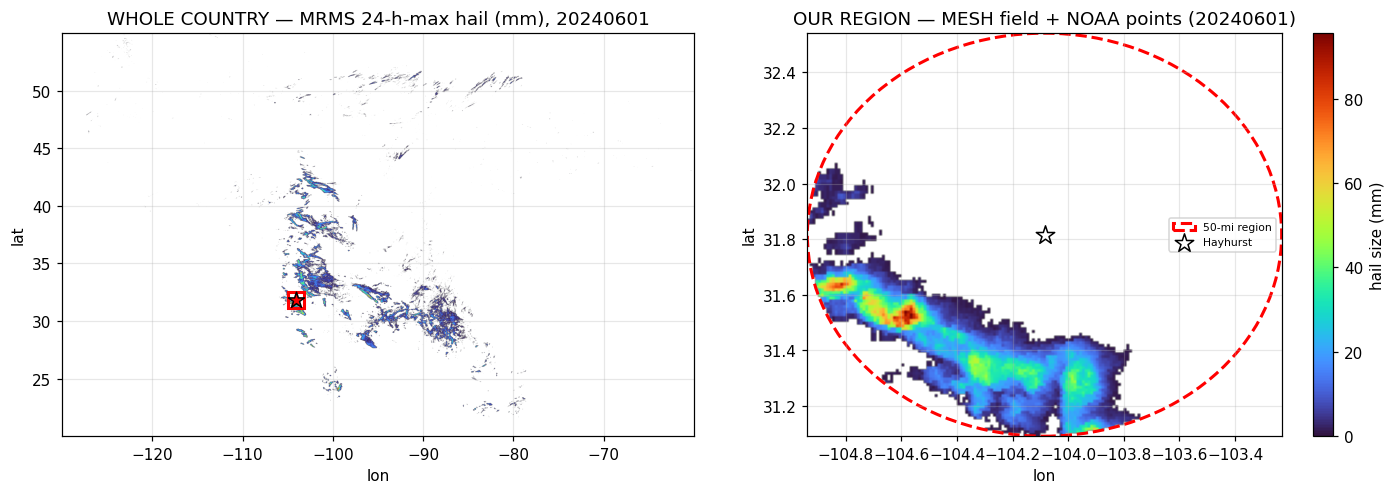

NOAA reports in region this day: 0  ·  MRMS hail cells in region this day: 3766
→ MRMS paints hail across space; NOAA marks only spots a person reported. Same storm, two data kinds.


In [7]:
def to_nan(a): return np.where(a < 0, np.nan, a)
sub0, arr0 = mrms.subset_box(da0, BOX)
arr0 = np.where(region_mask(sub0, ASSET["lat"], ASSET["lon"], RADIUS_MI), arr0, np.nan)   # → 50-mi circle
noaa = pd.read_parquet(ROOT / "data/hail/hayhurst_hail_m0_noaa_50mi.parquet")
noaa["datetime"] = pd.to_datetime(noaa["datetime"], utc=True)
noaa_day = noaa[noaa.datetime.dt.strftime("%Y%m%d") == SAMPLE]
dlat = RADIUS_MI / 69.0; dlon = RADIUS_MI / (69.0 * math.cos(math.radians(ASSET["lat"])))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].imshow(to_nan(full), origin="upper", extent=[lon0.min()-360, lon0.max()-360, lat0.min(), lat0.max()],
             cmap="turbo", vmin=0, vmax=80, aspect="auto")
ax[0].add_patch(plt.Rectangle((BOX["lon_lo"], BOX["lat_lo"]), BOX["lon_hi"]-BOX["lon_lo"], BOX["lat_hi"]-BOX["lat_lo"],
                              fill=False, ec="red", lw=2))
ax[0].scatter([ASSET["lon"]], [ASSET["lat"]], marker="*", s=120, color="red", ec="black")
ax[0].set(title=f"WHOLE COUNTRY — MRMS 24-h-max hail (mm), {SAMPLE}", xlabel="lon", ylabel="lat")
im = ax[1].imshow(arr0, origin="upper", extent=[BOX["lon_lo"], BOX["lon_hi"], BOX["lat_lo"], BOX["lat_hi"]],
                  cmap="turbo", vmin=0)
ax[1].add_patch(Ellipse((ASSET["lon"], ASSET["lat"]), 2*dlon, 2*dlat, fill=False, ec="red", ls="--", lw=2, label="50-mi region"))
ax[1].scatter([ASSET["lon"]], [ASSET["lat"]], marker="*", s=160, color="white", ec="black", zorder=6, label="Hayhurst")
if len(noaa_day):
    ax[1].scatter(noaa_day.lon, noaa_day.lat, marker="v", s=90, color="black", zorder=7, label="NOAA report")
ax[1].set(title=f"OUR REGION — MESH field + NOAA points ({SAMPLE})", xlabel="lon", ylabel="lat"); ax[1].legend(fontsize=7)
fig.colorbar(im, ax=ax[1], label="hail size (mm)"); plt.tight_layout(); plt.show()
print(f"NOAA reports in region this day: {len(noaa_day)}  ·  MRMS hail cells in region this day: {int((arr0>0).sum())}")
print("→ MRMS paints hail across space; NOAA marks only spots a person reported. Same storm, two data kinds.")

## 7 · From a *picture* to "events" — where the polygon comes from

The key idea, and the answer to *"is it event-based / do we have a polygon?"* — **MRMS gives neither; we
construct both.** Three steps on this day:

1. **The field** — raw mm values. Continuous; no "event."
2. **Threshold** — keep cells **≥ 25.4 mm** (1 in, severe) → a yes/no mask (a *shape*).
3. **Vectorize** — trace those cells into a **polygon** = the event **footprint**. *We* built it.

One day's above-threshold footprint = **one "hail-day" event** in the catalog (v1).

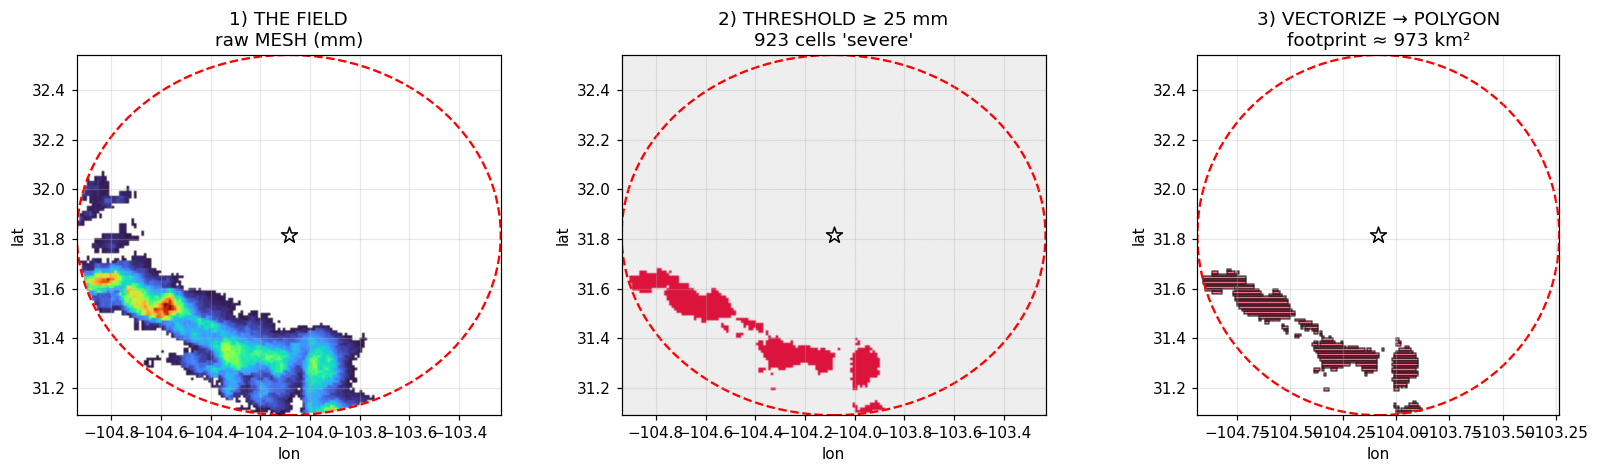

field → threshold (923 severe cells) → one polygon footprint of 973 km².
THIS polygon is the 'event' the M1 catalog stores. MRMS gave the field; we made the event + polygon.
(Speckled = severe cells are scattered → a MultiPolygon. Smoothing/'dilation' is a deliberate later step.)


In [8]:
above0 = np.isfinite(arr0) & (arr0 >= THRESHOLD_MM)
LO, LA = np.meshgrid(sub0.longitude.values, sub0.latitude.values); LO = np.where(LO > 180, LO - 360, LO)
dx = float(abs(LO[0,1]-LO[0,0])); dy = float(abs(LA[1,0]-LA[0,0]))
ys, xs = np.where(above0)
geom0 = unary_union([shp_box(LO[r,c]-dx/2, LA[r,c]-dy/2, LO[r,c]+dx/2, LA[r,c]+dy/2) for r, c in zip(ys, xs)])
area0 = float(gpd.GeoSeries([geom0], crs="EPSG:4326").to_crs("EPSG:5070").area.iloc[0]) / 1e6
ext = [BOX["lon_lo"], BOX["lon_hi"], BOX["lat_lo"], BOX["lat_hi"]]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
ax[0].imshow(arr0, origin="upper", extent=ext, cmap="turbo", vmin=0); ax[0].set_title("1) THE FIELD\nraw MESH (mm)")
ax[1].imshow(above0.astype(float), origin="upper", extent=ext, cmap=ListedColormap(["#eeeeee", "crimson"]))
ax[1].set_title(f"2) THRESHOLD ≥ {THRESHOLD_MM:.0f} mm\n{int(above0.sum())} cells 'severe'")
gpd.GeoSeries([geom0], crs="EPSG:4326").plot(ax=ax[2], fc="crimson", ec="black", alpha=0.6)
ax[2].set_title(f"3) VECTORIZE → POLYGON\nfootprint ≈ {area0:.0f} km²")
for a in ax:
    a.add_patch(Ellipse((ASSET["lon"], ASSET["lat"]), 2*dlon, 2*dlat, fill=False, ec="red", ls="--", lw=1.5))
    a.scatter([ASSET["lon"]], [ASSET["lat"]], marker="*", s=120, color="white", ec="black", zorder=6)
    a.set(xlabel="lon", ylabel="lat", xlim=(BOX["lon_lo"], BOX["lon_hi"]), ylim=(BOX["lat_lo"], BOX["lat_hi"]))
plt.tight_layout(); plt.show()
print(f"field → threshold ({int(above0.sum())} severe cells) → one polygon footprint of {area0:.0f} km².")
print("THIS polygon is the 'event' the M1 catalog stores. MRMS gave the field; we made the event + polygon.")
print("(Speckled = severe cells are scattered → a MultiPolygon. Smoothing/'dilation' is a deliberate later step.)")

---
## 8 · Scan the window → daily hail over the Hayhurst region  *(now we explore)*

With the data understood, the working pass: for each day, read the daily-max tile, subset to the 50-mi
circle, and record the region-max MESH and above-threshold footprint. Resilient — days with no tile / read
error are skipped **and reported** (no silent gaps). The bar chart is the **time dimension**: one bar per
tile/day; red bars clear the threshold and become events.

scanned 91 days = 91 read + 0 skipped; skipped: []
days with ≥25.4mm hail in region: 11


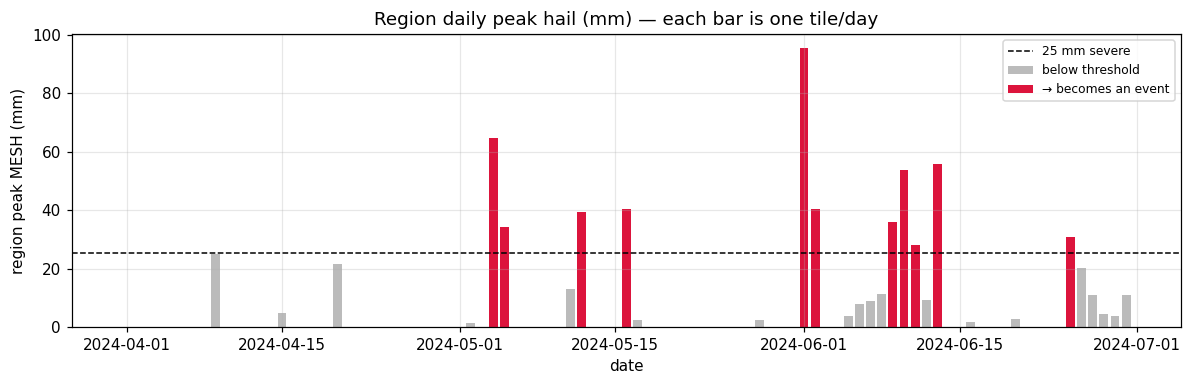

In [9]:
dates = [d.strftime("%Y%m%d") for d in pd.date_range(WINDOW[0], WINDOW[1], freq="D")]
rows, skipped = [], []
for ymd in dates:
    try:
        gz = mrms.get_day(ymd)
        if gz is None:
            skipped.append((ymd, "no tile")); continue
        sub, arr = mrms.subset_box(mrms.read_grid(gz)[1], BOX)
        arr = np.where(region_mask(sub, ASSET["lat"], ASSET["lon"], RADIUS_MI), arr, np.nan)  # box → 50-mi circle
        if not np.isfinite(arr).any():
            rows.append({"date": ymd, "region_max_mm": np.nan, "n_above_px": 0, "footprint_km2": 0.0}); continue
        above = arr >= THRESHOLD_MM
        rows.append({"date": ymd, "region_max_mm": float(np.nanmax(arr)),
                     "n_above_px": int(np.nansum(above)), "footprint_km2": round(float(np.nansum(above)) * PX_KM2, 1)})
    except Exception as e:
        skipped.append((ymd, str(e)[:50]))
daily = pd.DataFrame(rows); daily["date"] = pd.to_datetime(daily["date"])
print(f"scanned {len(dates)} days = {len(daily)} read + {len(skipped)} skipped; skipped: {skipped[:5]}{' …' if len(skipped)>5 else ''}")
print(f"days with ≥{THRESHOLD_MM}mm hail in region: {(daily.n_above_px>0).sum()}")

fig, ax = plt.subplots(figsize=(11, 3.6))
pk = daily.set_index("date")["region_max_mm"].fillna(0.0)
ev = pk >= THRESHOLD_MM
ax.bar(pk.index[~ev], pk[~ev], width=0.8, color="#bbb", label="below threshold")
ax.bar(pk.index[ev], pk[ev], width=0.8, color="crimson", label="→ becomes an event")
ax.axhline(THRESHOLD_MM, color="black", ls="--", lw=1, label=f"{THRESHOLD_MM:.0f} mm severe")
ax.set(title="Region daily peak hail (mm) — each bar is one tile/day", xlabel="date", ylabel="region peak MESH (mm)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 9 · Events — above-threshold days, with **footprints** (the thing NOAA couldn't give)

Each above-threshold day is an exploration-grade "event": footprint = above-threshold pixel area, peak =
region-max MESH. (The full dilation / connected-component event-assembly is the later M0→M1 catalog step.)
Every statistic is computed over the **50-mi circle** (identical region to NOAA in 01).

11 hail-event days in 2024-04-01…2024-06-30 within 50 mi of Hayhurst


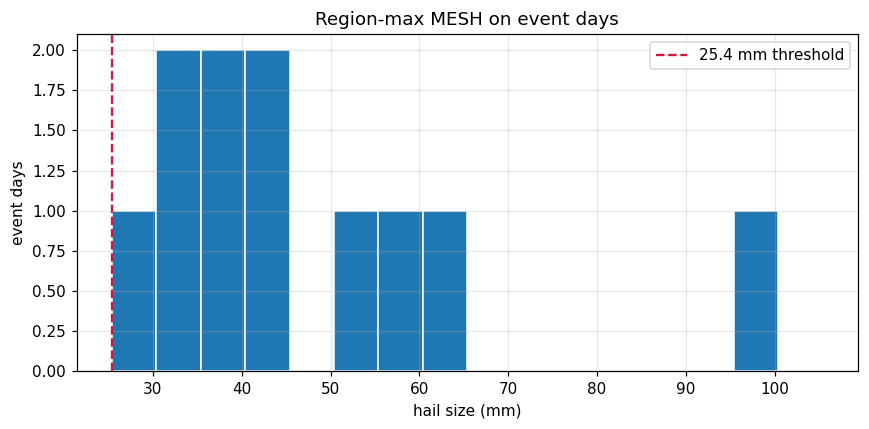

{'count': 11.0, 'mean': 47.2, 'std': 19.6, 'min': 28.1, '25%': 35.1, '50%': 40.4, '75%': 54.9, 'max': 95.5}


,date,region_max_mm,n_above_px,footprint_km2
61,2024-06-01,95.500000,923,971.9
33,2024-05-04,64.800003,433,456.0
73,2024-06-13,55.900002,399,420.2
70,2024-06-10,53.799999,373,392.8
45,2024-05-16,40.400002,65,68.4
62,2024-06-02,40.400002,76,80.0
41,2024-05-12,39.400002,78,82.1
69,2024-06-09,35.900002,37,39.0
34,2024-05-05,34.299999,34,35.8
85,2024-06-25,30.900000,4,4.2


In [10]:
events = daily[daily.n_above_px > 0].copy().sort_values("region_max_mm", ascending=False)
print(f"{len(events)} hail-event days in {WINDOW[0]}…{WINDOW[1]} within {RADIUS_MI} mi of Hayhurst")
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(events["region_max_mm"], bins=np.arange(THRESHOLD_MM, events.region_max_mm.max()+10, 5), edgecolor="white")
ax.axvline(THRESHOLD_MM, color="crimson", ls="--", label=f"{THRESHOLD_MM} mm threshold")
ax.set(title="Region-max MESH on event days", xlabel="hail size (mm)", ylabel="event days"); ax.legend()
plt.tight_layout(); plt.show()
print(events["region_max_mm"].describe().round(1).to_dict())
events.head(12)

## 10 · M0 event record (with footprint) → `data/hail/`

The MRMS M0 record carries what NOAA's couldn't: a **footprint area** (`F`) + gridded intensity — the inputs
the Minkowski coupling consumes. These per-day proto-events are exactly what the
[M1 catalog](../m1_catalog/01_event_catalog.ipynb) reads and turns into canonical events (with real
polygons, centroids, and the NOAA cross-check).

In [11]:
M0 = events.assign(
    event_id=lambda d: "mrms_hail_" + d["date"].dt.strftime("%Y%m%d"),
    peril="hail", source="MRMS_MESH_1440min", peak_mesh_mm=lambda d: d["region_max_mm"],
)[["event_id", "date", "peril", "source", "footprint_km2", "peak_mesh_mm", "n_above_px"]]
out = ROOT / "data" / "hail"; out.mkdir(parents=True, exist_ok=True)
fn_out = f"hayhurst_hail_m0_mrms_{WINDOW[0][:7].replace('-','')}_{WINDOW[1][:7].replace('-','')}.parquet"
M0.to_parquet(out / fn_out, index=False)
print(f"MRMS M0 event records: {len(M0)} → {out / fn_out}")
M0.head()

MRMS M0 event records: 11 → /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hail/hayhurst_hail_m0_mrms_202404_202406.parquet


,event_id,date,peril,source,footprint_km2,peak_mesh_mm,n_above_px
61,mrms_hail_20240601,2024-06-01,hail,MRMS_MESH_1440min,971.9,95.500000,923
33,mrms_hail_20240504,2024-05-04,hail,MRMS_MESH_1440min,456.0,64.800003,433
73,mrms_hail_20240613,2024-06-13,hail,MRMS_MESH_1440min,420.2,55.900002,399
70,mrms_hail_20240610,2024-06-10,hail,MRMS_MESH_1440min,392.8,53.799999,373
45,mrms_hail_20240516,2024-05-16,hail,MRMS_MESH_1440min,68.4,40.400002,65


## 11 · Recap — the three questions, + findings & what's carried forward

| Question | Answer (shown above) |
|---|---|
| **What does MRMS look like?** | A **grid of numbers** — a ~1 km hail-size (mm) value at every pixel over CONUS, one grid per timestamp (the `1440min` product = trailing 24-h max). A *picture*, not a table (§4–§6). |
| **Is it event-based?** | **No** — a continuous *field*. We **impose** events by thresholding (≥ 25.4 mm) and calling each day's severe footprint a "hail-day" (§7–§9). |
| **Do we have a polygon?** | **Not from MRMS.** *We* trace the above-threshold cells into a footprint polygon (§7); the M1 catalog persists it. |

**Findings & open questions (→ M0→M1):**
- **MRMS gives footprints.** Each event carries an above-threshold **footprint area** (`F`) + gridded MESH —
  the `F` the Minkowski coupling needs. *This is the reason to use MRMS.*
- **Coverage** ~2020-10 → present; we scanned **Apr–Jun 2024 only** (stated bound; widen `WINDOW`). Short
  record is the central caveat — `learning_logs/01`.
- **vs NOAA (01):** NOAA = point reports, longer record (1996→), no footprint, population-biased; MRMS =
  gridded footprints, shorter record, complete coverage. Complementary — reconciling them is the
  **M0→M1** step (the [catalog](../m1_catalog/01_event_catalog.ipynb)), where NOAA cross-checks the spine.
- **Open:** daily-grain choice (last-tile vs true daily max over all tiles); dilation + connected-component
  event-assembly deferred to the catalog step.